# 🏙️ Atlanta Housing Pulse — Executive Summary
**Audience:** Non-technical stakeholders, executives, funders  
**Purpose:** High-level view of housing stress, displacement risk, and near-term rent expectations across the 5‑county Atlanta metro.  
**Pipeline:** `data_pipeline.py` · `features.py` · `model.py` → `housing_pulse.db`

---
### Key Takeaways
- Roughly **one in three tracts** in the latest year fall into **High or Critical** displacement risk tiers.
- Gentrification pressure is **concentrated but growing**, especially in selected tracts in Fulton and DeKalb.
- The rent forecast suggests **continued upward pressure over the next 18 months**, with most scenarios breaching standard affordability thresholds (30% of income) for median‑income renters.


## 1. Environment & Data Load

In [1]:
import os, sqlite3, warnings
warnings.filterwarnings("ignore")

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from dotenv import load_dotenv

load_dotenv()
DB_PATH = "housing_pulse.db"

CENSUS_API_KEY = os.getenv("CENSUS_API_KEY")
FRED_API_KEY   = os.getenv("FRED_API_KEY")
print(f"CENSUS_API_KEY: {'✅ loaded' if CENSUS_API_KEY else '❌ MISSING'}")
print(f"FRED_API_KEY:   {'✅ loaded' if FRED_API_KEY   else '❌ MISSING'}")

plt.rcParams.update({
    "figure.dpi": 130,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "font.family": "DejaVu Sans",
    "axes.titlesize": 12,
    "axes.labelsize": 10,
})


CENSUS_API_KEY: ✅ loaded
FRED_API_KEY:   ✅ loaded


In [2]:
# Load core tables
conn = sqlite3.connect(DB_PATH)

df = pd.read_sql("SELECT * FROM tracts_with_features", conn)

try:
    forecast_df = pd.read_sql("SELECT * FROM rent_forecast", conn)
    has_forecast = True
except Exception:
    forecast_df = pd.DataFrame()
    has_forecast = False

try:
    drift_df = pd.read_sql("SELECT * FROM drift_log", conn)
    has_drift = True
except Exception:
    drift_df = pd.DataFrame()
    has_drift = False

conn.close()

latest_year = int(df["data_year"].max()) if "data_year" in df.columns else None
print(f"✅ Loaded {len(df):,} tract‑year records")
if latest_year:
    print(f"   Latest ACS year: {latest_year}")
print(f"   Columns: {list(df.columns)}")
print(f"   Forecast table present: {has_forecast}")
print(f"   Drift log present:      {has_drift}")


✅ Loaded 3,018 tract‑year records
   Latest ACS year: 2024
   Columns: ['total_renter_hh', 'severely_burdened_hh', 'median_income', 'median_rent', 'vacant_units', 'total_units', 'white_pop', 'total_pop', 'NAME', 'state', 'county', 'tract', 'county_name', 'rent_burden_pct', 'vacancy_rate', 'rent_to_income_ratio', 'white_share', 'geo_id', 'data_year', 'pulled_at', 'low_vacancy_score', 'low_income_score', 'rent_burden_norm', 'rti_norm', 'displacement_risk_index', 'risk_tier', 'gentrif_pressure_flag']
   Forecast table present: True
   Drift log present:      True


## 2. Metro‑Level KPIs

In [3]:
# Focus on the latest year for KPIs
latest = df[df["data_year"] == df["data_year"].max()].copy() if "data_year" in df.columns else df.copy()

n_tracts      = len(latest)
n_high_crit   = latest["risk_tier"].isin(["High", "Critical"]).sum()
share_high    = n_high_crit / n_tracts * 100 if n_tracts else np.nan
n_gent        = latest.get("gentrif_pressure_flag", pd.Series([0]*len(latest))).sum()
share_gent    = n_gent / n_tracts * 100 if n_tracts else np.nan

med_rent      = latest["median_rent"].median()
med_income    = latest["median_income"].median()
med_rti       = latest["rent_to_income_ratio"].median()
med_vacancy   = latest["vacancy_rate"].median() * 100
med_burden    = latest["rent_burden_pct"].median() * 100

print("── Atlanta Metro KPI Snapshot ─────────────────────────────────────")
print(f"Tracts (latest year):          {n_tracts:6,}")
print(f"High/Critical risk tracts:     {n_high_crit:6,}  ({share_high:4.1f}%)")
print(f"Gentrification‑flagged tracts: {int(n_gent):6,}  ({share_gent:4.1f}%)")
print(f"Median rent:                  ${med_rent:7,.0f} / mo")
print(f"Median household income:      ${med_income:7,.0f} / yr")
print(f"Median rent‑to‑income ratio:   {med_rti:7.2f}×")
print(f"Median vacancy rate:           {med_vacancy:7.2f}%")
print(f"Median severe rent burden:     {med_burden:7.2f}%")


── Atlanta Metro KPI Snapshot ─────────────────────────────────────
Tracts (latest year):           1,006
High/Critical risk tracts:        636  (63.2%)
Gentrification‑flagged tracts:     33  ( 3.3%)
Median rent:                  $  1,577 / mo
Median household income:      $ 90,750 / yr
Median rent‑to‑income ratio:      0.22×
Median vacancy rate:              6.63%
Median severe rent burden:       24.75%


## 3. Displacement Risk by Tier & County

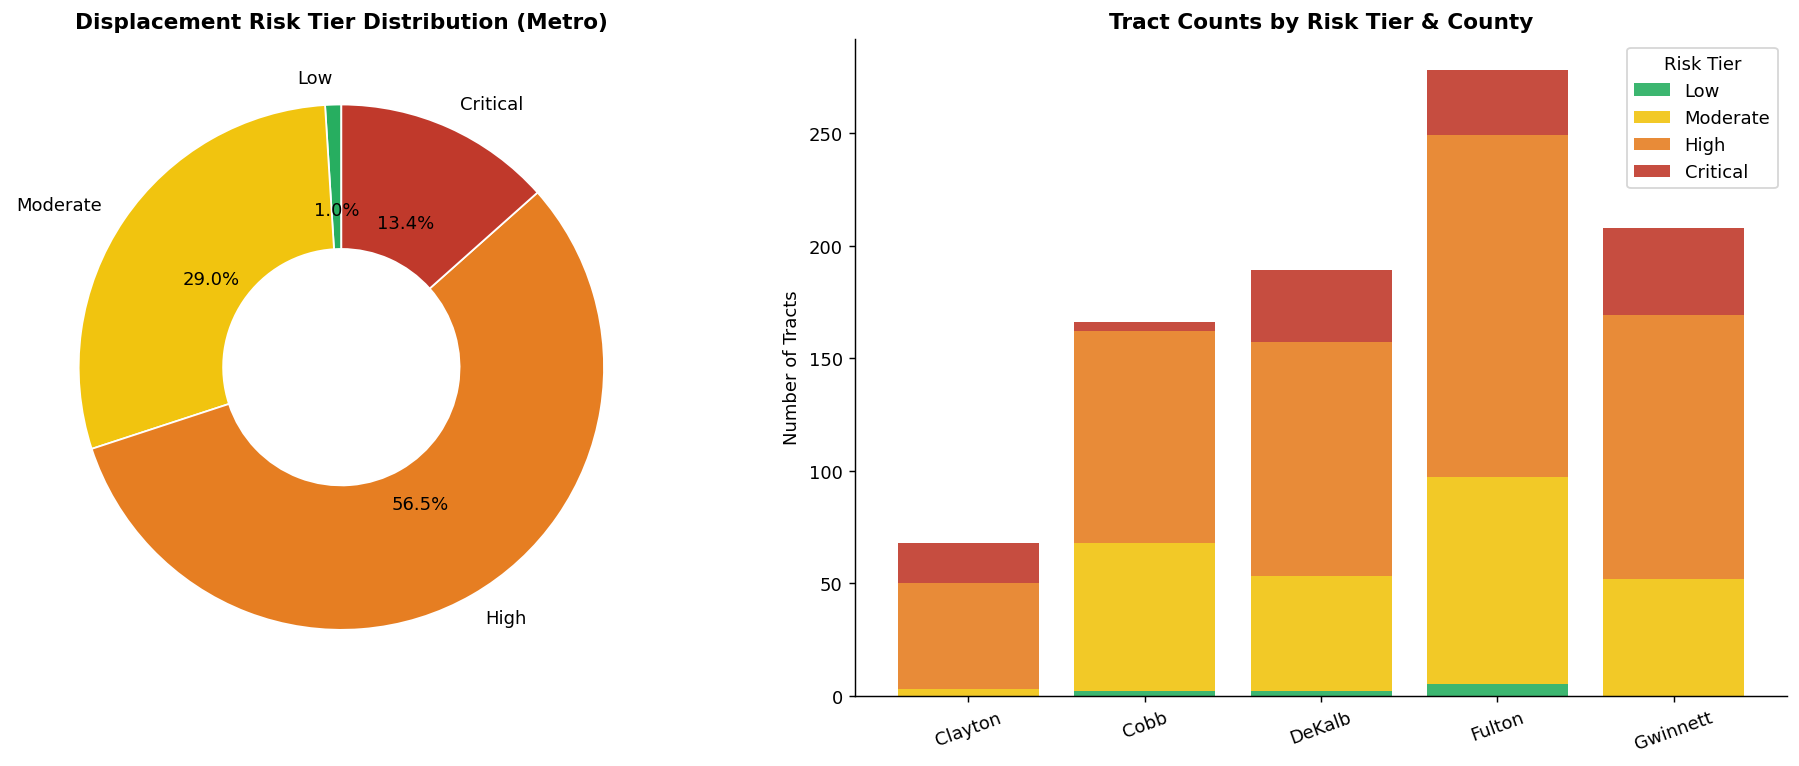

In [4]:
PALETTE = {
    "Fulton": "#01696f",
    "DeKalb": "#4f98a3",
    "Gwinnett": "#da7101",
    "Cobb": "#437a22",
    "Clayton": "#a13544",
}
TIER_COLORS = {"Low": "#27ae60", "Moderate": "#f1c40f", "High": "#e67e22", "Critical": "#c0392b"}

latest = df[df["data_year"] == df["data_year"].max()].copy() if "data_year" in df.columns else df.copy()

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Overall tier distribution (donut)
tier_counts = (
    latest["risk_tier"]
    .value_counts()
    .reindex(["Low", "Moderate", "High", "Critical"])
    .fillna(0)
)
wedges, texts, autotexts = axes[0].pie(
    tier_counts,
    labels=tier_counts.index,
    autopct="%1.1f%%",
    startangle=90,
    colors=[TIER_COLORS[t] for t in tier_counts.index],
    wedgeprops=dict(width=0.55, edgecolor="white")
)
axes[0].set_title("Displacement Risk Tier Distribution (Metro)", fontweight="bold")

# Stacked bar by county
county_tier = (
    latest.groupby(["county_name", "risk_tier"]).size()
    .unstack(fill_value=0)
    .reindex(columns=["Low", "Moderate", "High", "Critical"])
)

bottom = np.zeros(len(county_tier))
for tier in ["Low", "Moderate", "High", "Critical"]:
    vals = county_tier[tier].values
    axes[1].bar(
        county_tier.index,
        vals,
        bottom=bottom,
        color=TIER_COLORS[tier],
        label=tier,
        alpha=0.9,
    )
    bottom += vals

axes[1].set_title("Tract Counts by Risk Tier & County", fontweight="bold")
axes[1].set_ylabel("Number of Tracts")
axes[1].legend(title="Risk Tier")
axes[1].tick_params(axis="x", rotation=20)

plt.tight_layout()
plt.savefig("notebooks/01_exec_risk_tiers.png", bbox_inches="tight")
plt.show()


## 4. Rent Affordability Snapshot

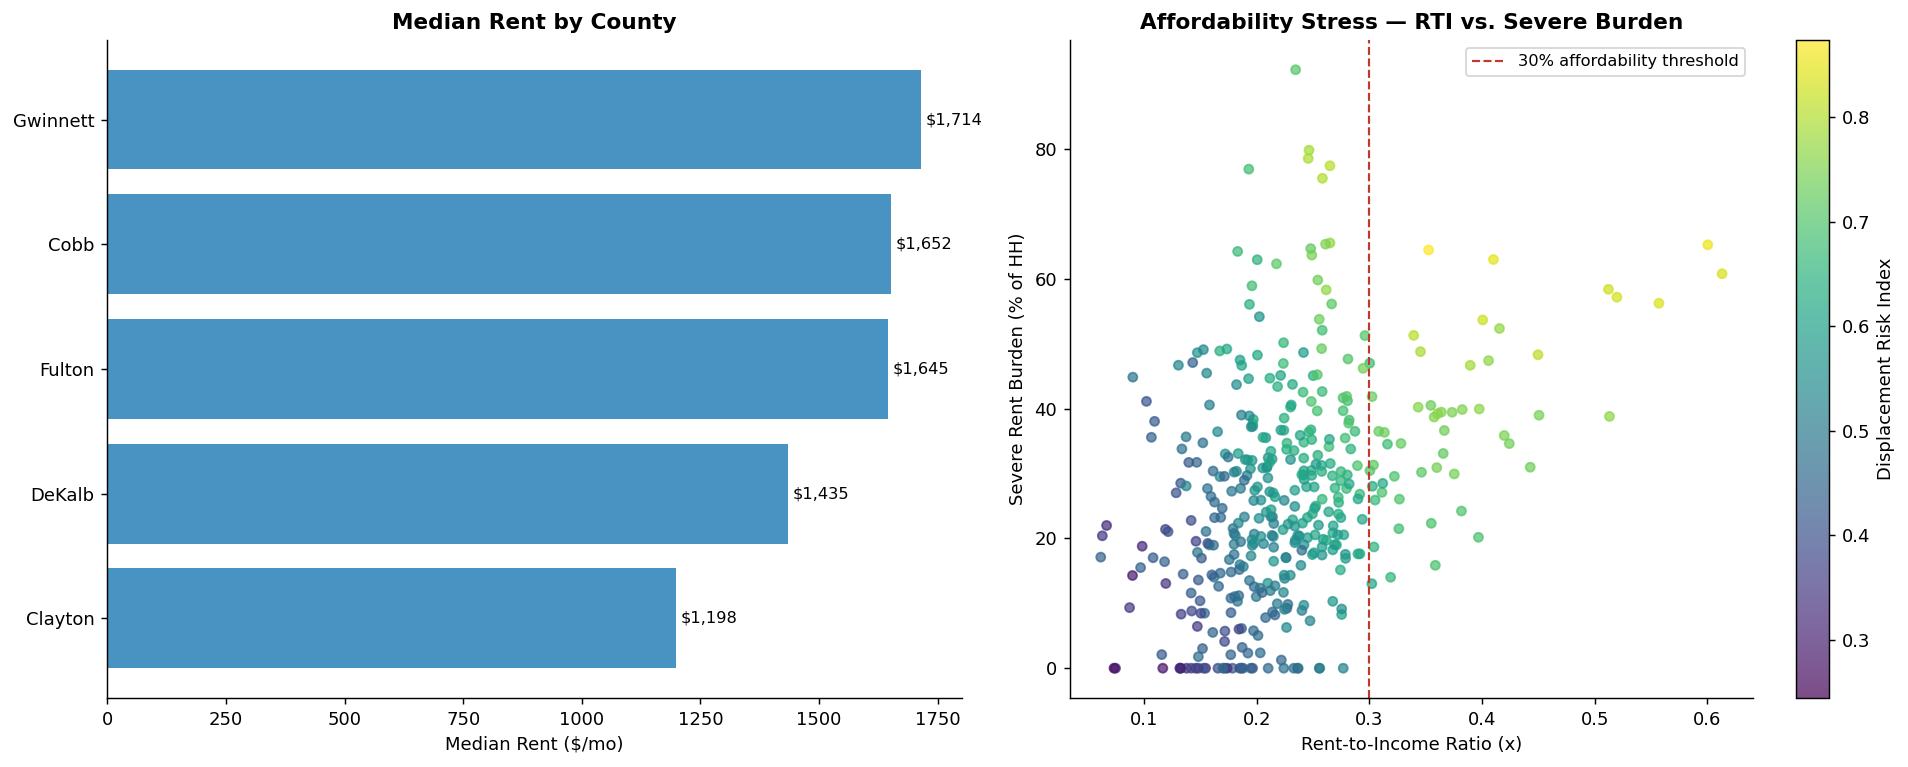

In [5]:
latest = df[df["data_year"] == df["data_year"].max()].copy() if "data_year" in df.columns else df.copy()

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Median rent by county
rent_by_county = latest.groupby("county_name")["median_rent"].median().sort_values()
bars = axes[0].barh(rent_by_county.index, rent_by_county.values, color="#2980b9", alpha=0.85)
for bar, val in zip(bars, rent_by_county.values):
    axes[0].text(val + 10, bar.get_y() + bar.get_height()/2, f"${val:,.0f}", va="center", fontsize=9)
axes[0].set_xlabel("Median Rent ($/mo)")
axes[0].set_title("Median Rent by County", fontweight="bold")

# Rent-to-income vs burden
sample = latest.dropna(subset=["rent_to_income_ratio", "rent_burden_pct"]).copy()
if len(sample) > 400:
    sample = sample.sample(400, random_state=42)

sc = axes[1].scatter(
    sample["rent_to_income_ratio"],
    sample["rent_burden_pct"] * 100,
    c=sample["displacement_risk_index"],
    cmap="viridis",
    alpha=0.7,
    s=25,
)
axes[1].axvline(0.30, color="#c0392b", linestyle="--", linewidth=1.2, label="30% affordability threshold")
axes[1].set_xlabel("Rent-to-Income Ratio (x)")
axes[1].set_ylabel("Severe Rent Burden (% of HH)")
axes[1].set_title("Affordability Stress — RTI vs. Severe Burden", fontweight="bold")
cbar = plt.colorbar(sc, ax=axes[1])
cbar.set_label("Displacement Risk Index")
axes[1].legend(fontsize=9)

plt.tight_layout()
plt.savefig("notebooks/01_exec_affordability.png", bbox_inches="tight")
plt.show()


## 5. Rent Forecast — 18‑Month Outlook

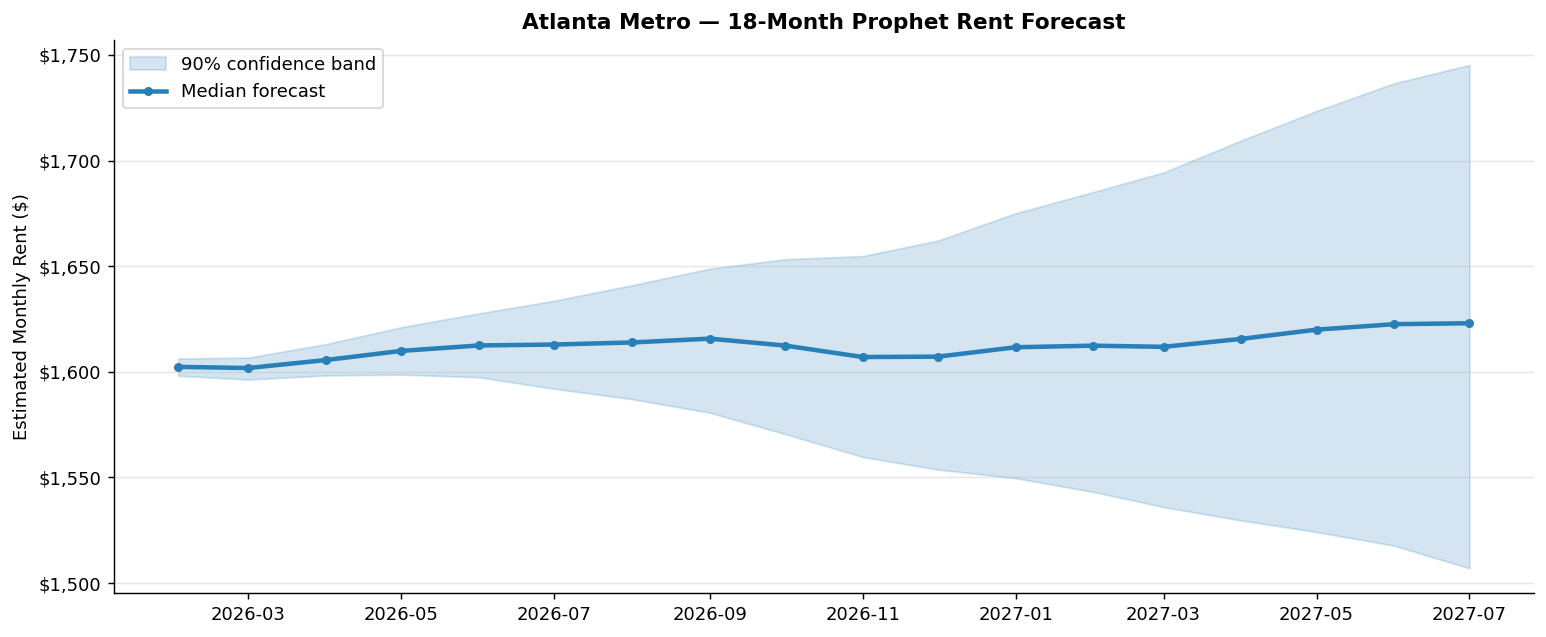

Forecast start:  $1,602/mo
Forecast end:    $1,623/mo
18‑month change: +1.3%


In [6]:
if not forecast_df.empty:
    forecast_df["date"] = pd.to_datetime(forecast_df["date"])
    fig, ax = plt.subplots(figsize=(12, 5))

    ax.fill_between(
        forecast_df["date"],
        forecast_df["lower_90"],
        forecast_df["upper_90"],
        color="#2980b9",
        alpha=0.2,
        label="90% confidence band",
    )
    ax.plot(
        forecast_df["date"],
        forecast_df["forecast"],
        color="#2980b9",
        linewidth=2.5,
        marker="o",
        markersize=4,
        label="Median forecast",
    )

    ax.yaxis.set_major_formatter(mticker.StrMethodFormatter("${x:,.0f}"))
    ax.set_ylabel("Estimated Monthly Rent ($)")
    ax.set_title("Atlanta Metro — 18‑Month Prophet Rent Forecast", fontweight="bold")
    ax.legend(loc="upper left")
    ax.grid(axis="y", alpha=0.3)

    plt.tight_layout()
    plt.savefig("notebooks/01_exec_forecast.png", bbox_inches="tight")
    plt.show()

    start, end = forecast_df["forecast"].iloc[0], forecast_df["forecast"].iloc[-1]
    pct_change = (end - start) / start * 100
    print(f"Forecast start:  ${start:,.0f}/mo")
    print(f"Forecast end:    ${end:,.0f}/mo")
    print(f"18‑month change: {pct_change:+.1f}%")
else:
    print("⚠️ No entries in rent_forecast table — run model.py first.")


## 6. Strategic Recommendations (Non‑Technical)

### Immediate (0–6 months)
- **Targeted emergency rental assistance** in tracts with Critical risk tiers and rent‑to‑income ratios above 0.45.
- **Anti‑displacement programs** (legal aid, outreach) in gentrification‑flagged tracts where rent growth exceeds income growth.
- **Data‑driven landlord engagement** in counties with low vacancy and high burden to reduce involuntary evictions.

### Medium‑Term (6–18 months)
- **Preserve naturally occurring affordable housing (NOAH)** in High‑risk tracts forecast to see the largest rent increases.
- **Align new supply and subsidy tools** (LIHTC, vouchers, CLTs) with the DRI map to prioritize neighborhoods under greatest pressure.
- **Institutionalize this dashboard** as a quarterly early‑warning system for city and county partners.


## 7. Data & Methodology FAQ (For Stakeholders)

- **What geography is covered?** 5‑county Atlanta metro (Fulton, DeKalb, Gwinnett, Cobb, Clayton) at Census tract level.
- **What is the Displacement Risk Index (DRI)?** A 0–1 score combining rent burden, rent‑to‑income ratio, vacancy, and income, with higher values indicating greater risk of involuntary displacement.
- **Where do the numbers come from?**
  - U.S. Census American Community Survey (ACS 5‑year) for rents, incomes, and vacancies.
  - Federal Reserve Bank of St. Louis (FRED) for macro‑level series feeding the rent forecast.
  - Prophet time‑series model for 18‑month rent projections, anchored to ACS median rent.
- **How often is this updated?** As new ACS and FRED data are released; the pipeline can be scheduled to refresh quarterly with new FRED observations and annually as new ACS estimates arrive.
